# Adaptive Hedge — experiments

Three loss-sequence regimes (stochastic, adversarial-shifting, low-gap) compared across:
Hedge with several fixed learning rates (including the theory-optimal one) and AdaHedge.
We fix $K = 10$ experts throughout.
Each cell saves the figures into `../figures/` so that they can be used to produce the report.

Shaded bands are $\pm 1$ standard deviation across the `N_SEEDS` independent runs (no band for the deterministic adversarial run). Hedge variants use a blue gradient ordered by $\eta$ (light = small, dark = large). AdaHedge is the thicker red line.

In [15]:
%load_ext autoreload
%autoreload 2

import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.algorithms import Hedge, AdaHedge, hedge_eta_theory
from src.losses import stochastic_losses, adversarial_shifting, low_gap_losses
from src.experiments import (
    run_with_seeds, best_expert_cumloss, default_algos,
    plot_regret, plot_avg_loss, plot_cumloss,
)

FIGDIR = os.path.abspath('../figures')
os.makedirs(FIGDIR, exist_ok=True)

plt.rcParams['figure.dpi']  = 140
plt.rcParams['savefig.dpi'] = 200

def save_fig(fig, basename):
    """Save a figure as both PNG (raster, for previews) and PDF (vector, for LaTeX)."""
    fig.savefig(os.path.join(FIGDIR, f'{basename}.png'), bbox_inches='tight')
    fig.savefig(os.path.join(FIGDIR, f'{basename}.pdf'), bbox_inches='tight')

def regime_grid(loss_fn, label, basename, n_seeds=None):
    """Run a regime at K experts and plot a 1x3 panel (cumloss / avgloss / regret).

    `loss_fn(rng) -> losses (T, K)` is the (already-K-bound) loss generator.
    Returns {algo_name: final_regret} for the printed summary.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    algos = default_algos(T, K)
    seeds = N_SEEDS if n_seeds is None else n_seeds
    results = run_with_seeds(loss_fn, algos, n_seeds=seeds, base_seed=BASE_SEED)
    best = best_expert_cumloss(loss_fn, n_seeds=seeds, base_seed=BASE_SEED)
    final_regrets = {name: d['regret'][:, -1].mean() for name, d in results.items()}
    plot_cumloss (results, best, f'{label}, K={K} — cumulative loss', ax=axes[0])
    plot_avg_loss(results, best, f'{label}, K={K} — avg loss per round', ax=axes[1])
    plot_regret  (results,        f'{label}, K={K} — regret',           ax=axes[2])
    plt.tight_layout()
    save_fig(fig, basename)
    plt.show()
    print(f'Final regret R_T (mean over {seeds} seed{"s" if seeds>1 else ""}):')
    for name, r in final_regrets.items():
        print(f'  {name:35s}  {r:7.2f}')
    return final_regrets

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameters
Parameter used in the experiments are defined in the following cell.

The choices are motivated in the report

In [16]:
K = 10                   # number of experts
T = 2_000                # horizon
N_SEEDS = 20             # repetitions for stochastic regimes
BASE_SEED = 0

print(f'K={K}: eta_theory={hedge_eta_theory(T, K):.4f}, '
      f'theoretical regret bound (Hedge*) sqrt(T ln K / 2)={np.sqrt(T * np.log(K) / 2):.2f}')

K=10: eta_theory=0.0960, theoretical regret bound (Hedge*) sqrt(T ln K / 2)=47.99


## 1. Stochastic regime
Expert 0 has loss $\sim\mathrm{Bernoulli}(0.3)$, while all others $\sim\mathrm{Bernoulli}(0.5)$. The best expert is fixed and the gap is "large".

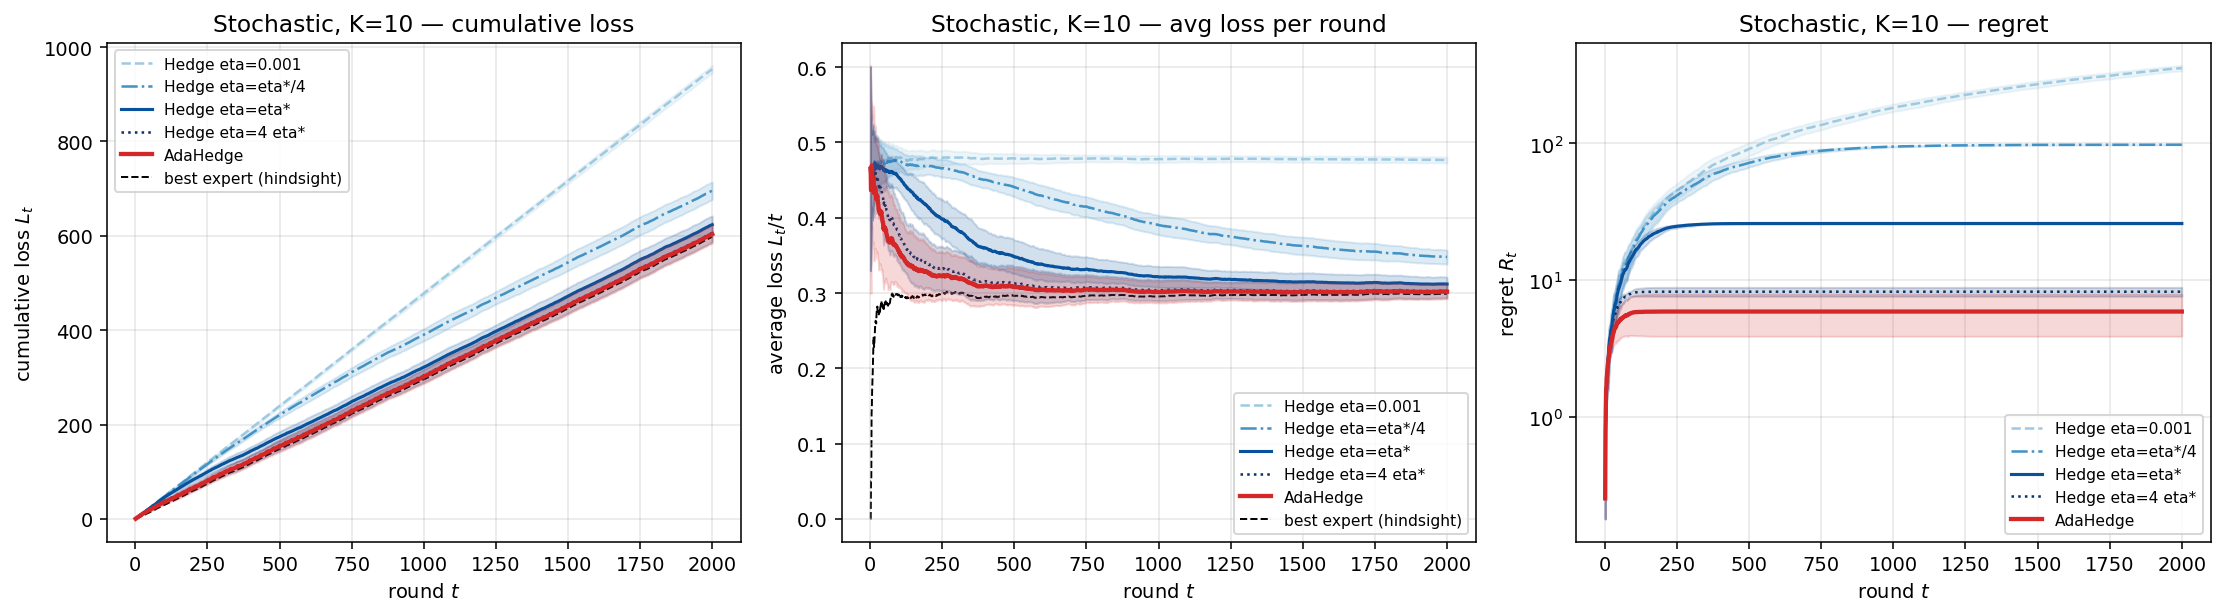

Final regret R_T (mean over 20 seeds):
  Hedge eta=0.001                       355.56
  Hedge eta=eta*/4                       97.84
  Hedge eta=eta*                         25.99
  Hedge eta=4 eta*                        8.24
  AdaHedge                                5.90


{'Hedge eta=0.001': np.float64(355.5595540209755),
 'Hedge eta=eta*/4': np.float64(97.83590978444002),
 'Hedge eta=eta*': np.float64(25.986554562568255),
 'Hedge eta=4 eta*': np.float64(8.244088197046818),
 'AdaHedge': np.float64(5.903470512731099)}

In [17]:
regime_grid(
    loss_fn=lambda rng: stochastic_losses(T, K, good_p=0.3, bad_p=0.5, rng=rng),
    label='Stochastic',
    basename='stochastic',
)

## 2a. Adversarial regime — slower shift (n=2)
Adversarial shifting with `n_segments=2`. There is a single shift in the middle of the horizon.

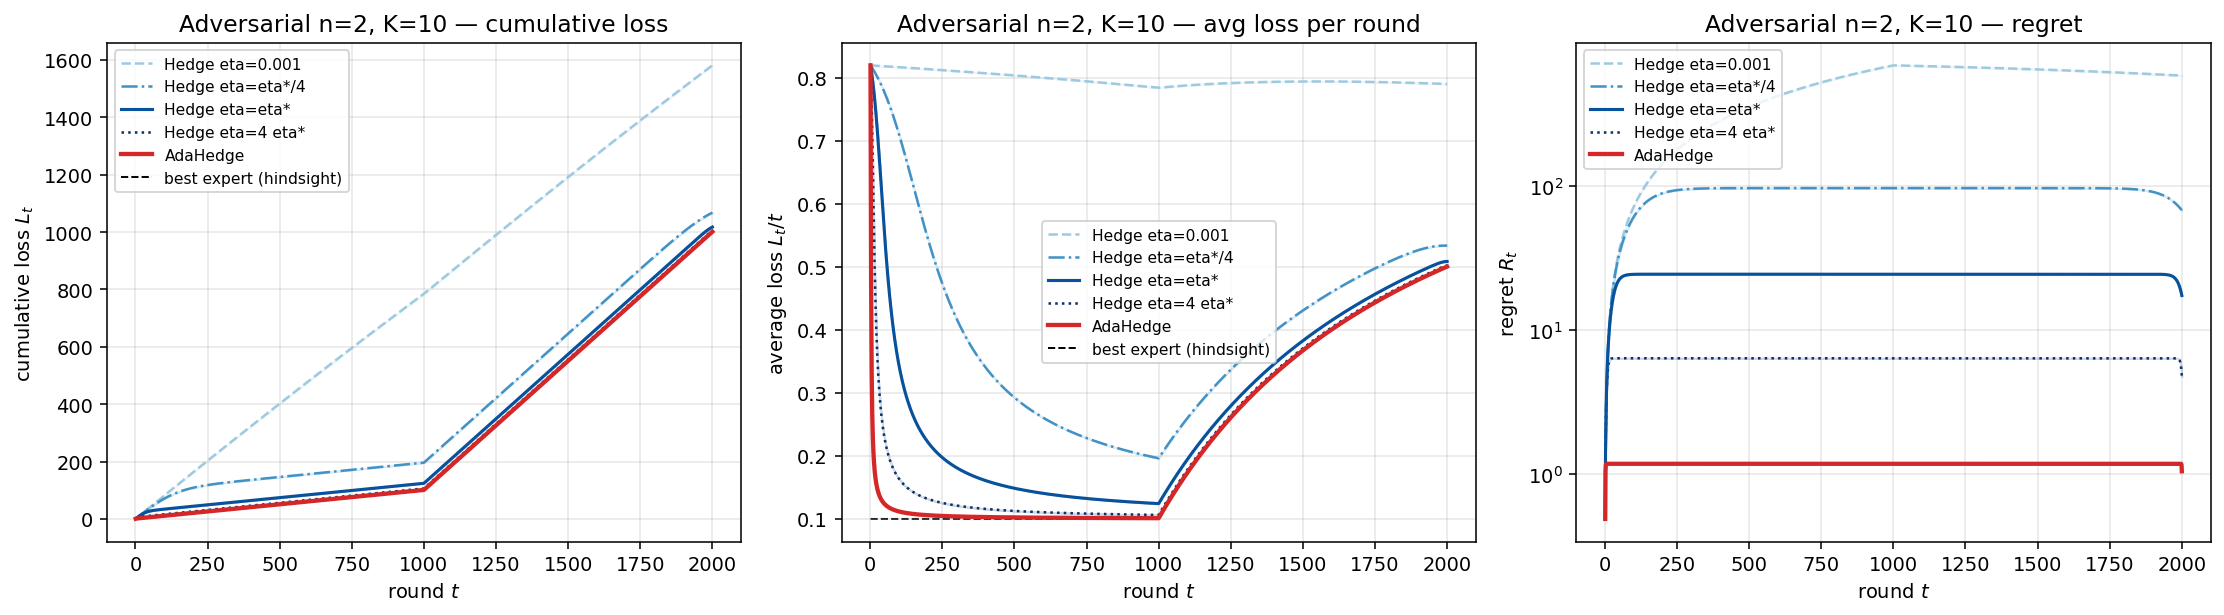

Final regret R_T (mean over 1 seed):
  Hedge eta=0.001                       580.85
  Hedge eta=eta*/4                       67.64
  Hedge eta=eta*                         17.33
  Hedge eta=4 eta*                        4.75
  AdaHedge                                1.05


{'Hedge eta=0.001': np.float64(580.8527373795165),
 'Hedge eta=eta*/4': np.float64(67.64030802310424),
 'Hedge eta=eta*': np.float64(17.329309356143654),
 'Hedge eta=4 eta*': np.float64(4.74925092522335),
 'AdaHedge': np.float64(1.0464042744532662)}

In [18]:
regime_grid(
    loss_fn=lambda rng: adversarial_shifting(T, K, n_segments=2, low=0.1, high=0.9),
    label='Adversarial n=2',
    basename='adversarial_n2',
    n_seeds=1,   # deterministic
)

## 2b. Adversarial regime — faster shifts (n=5)
Same as before, but in this case the "time" is split into 5 segments.

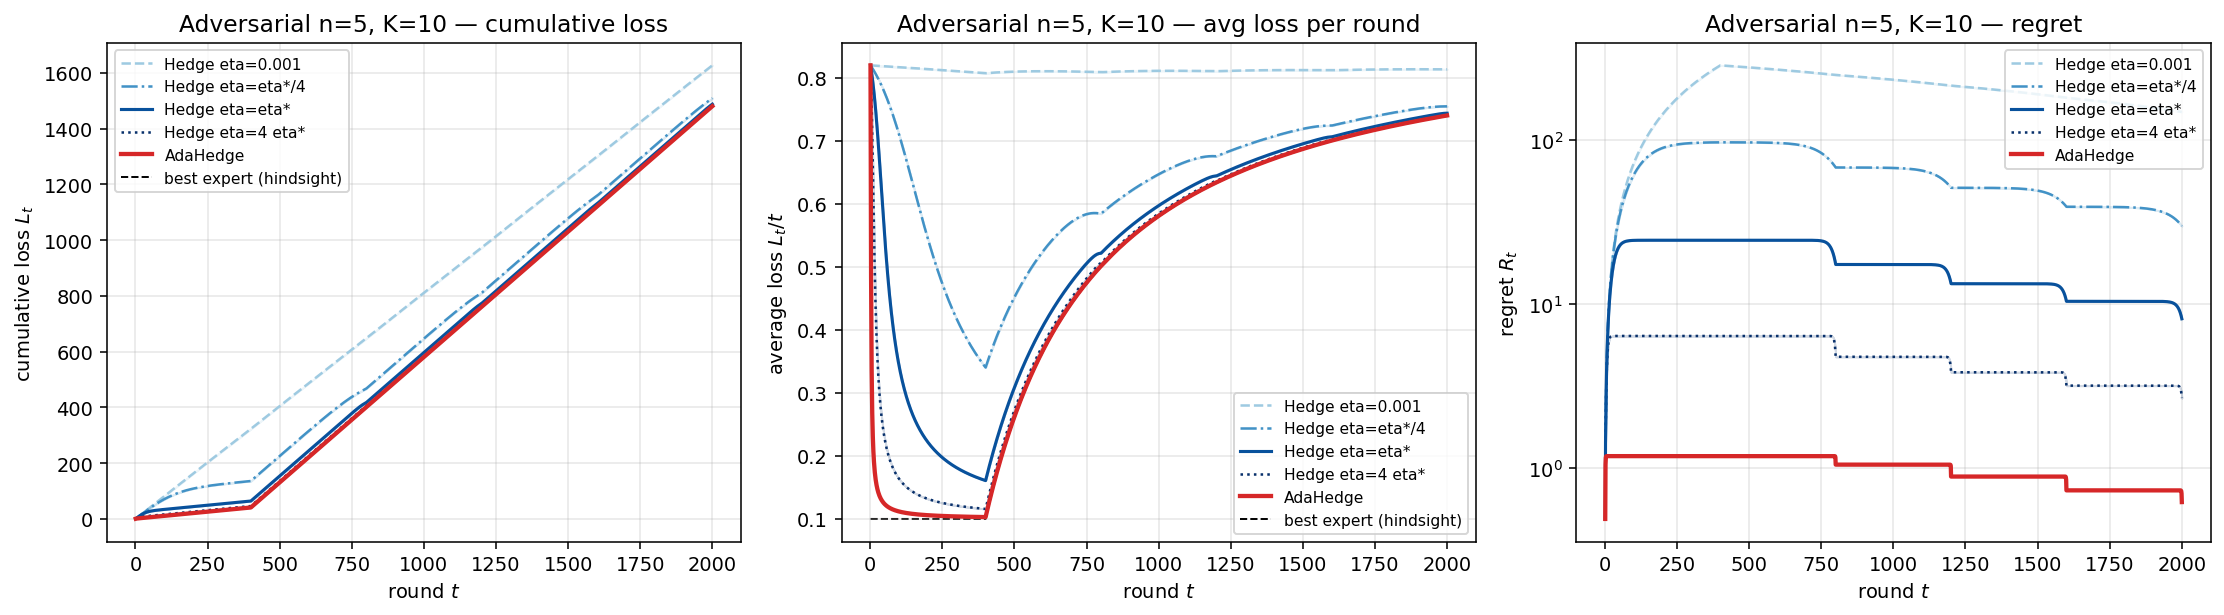

Final regret R_T (mean over 1 seed):
  Hedge eta=0.001                       147.32
  Hedge eta=eta*/4                       29.74
  Hedge eta=eta*                          8.09
  Hedge eta=4 eta*                        2.66
  AdaHedge                                0.81


{'Hedge eta=0.001': np.float64(147.31580655085168),
 'Hedge eta=eta*/4': np.float64(29.740439592058692),
 'Hedge eta=eta*': np.float64(8.092099346139321),
 'Hedge eta=4 eta*': np.float64(2.664010204568058),
 'AdaHedge': np.float64(0.8123488244186774)}

In [ ]:
regime_grid(
    loss_fn=lambda rng: adversarial_shifting(T, K, n_segments=5, low=0.1, high=0.9),
    label='Adversarial n=5',
    basename='adversarial',
    n_seeds=1,
)

## 3. Low-gap regime
Best expert is $\mathrm{Bernoulli}(0.49)$; the others $\mathrm{Bernoulli}(0.5)$. The gap is tiny relative to the noise, so distinguishing the best expert should be harder.

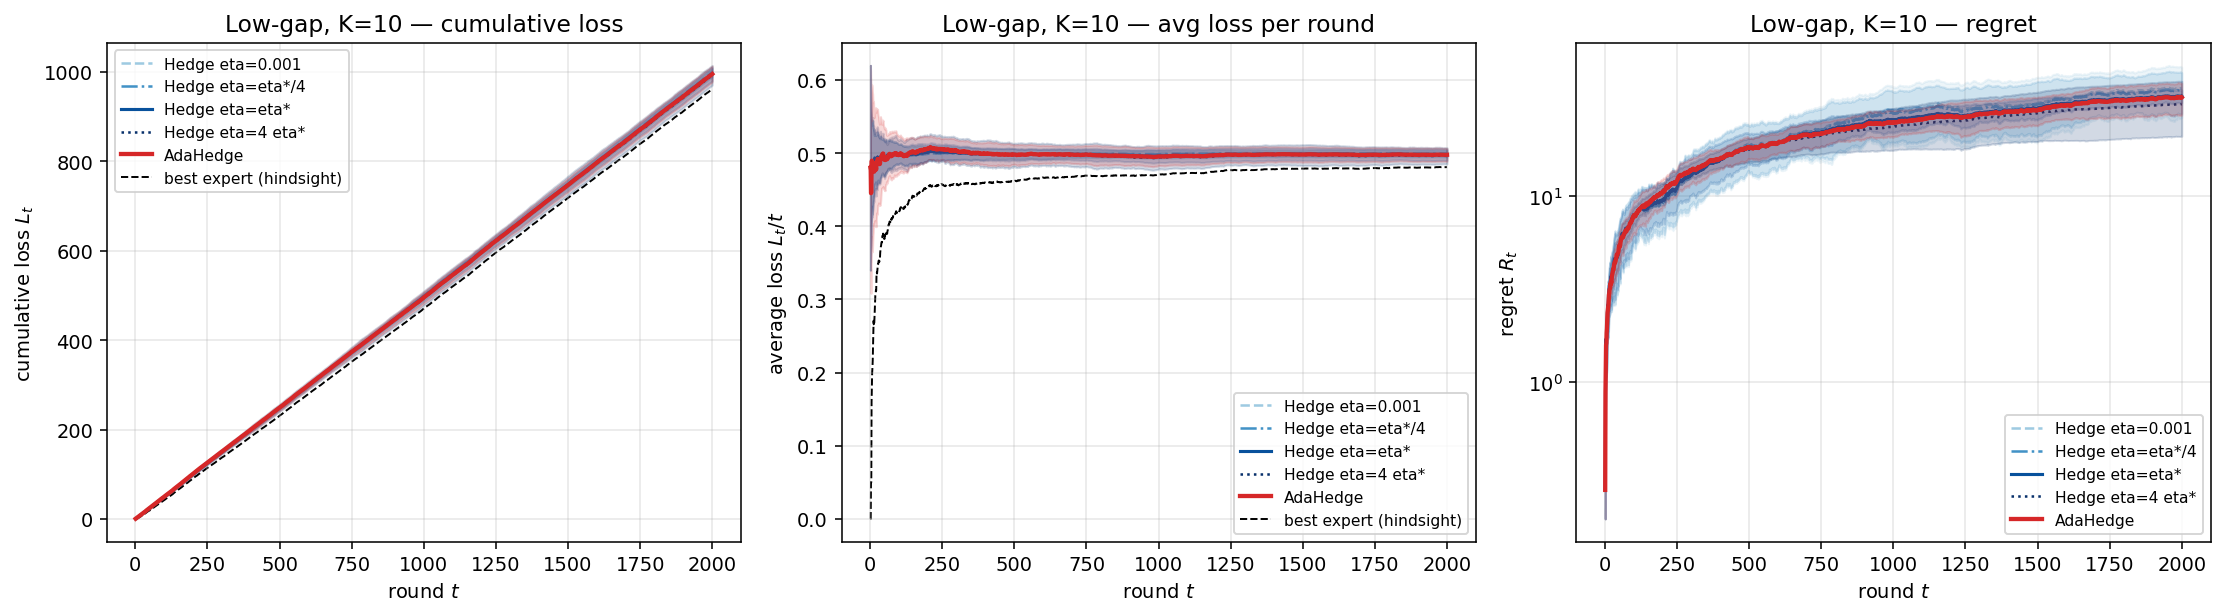

Final regret R_T (mean over 20 seeds):
  Hedge eta=0.001                        37.65
  Hedge eta=eta*/4                       36.78
  Hedge eta=eta*                         34.22
  Hedge eta=4 eta*                       31.00
  AdaHedge                               33.67


{'Hedge eta=0.001': np.float64(37.65245811212562),
 'Hedge eta=eta*/4': np.float64(36.78211702936276),
 'Hedge eta=eta*': np.float64(34.221573510380736),
 'Hedge eta=4 eta*': np.float64(31.003181475365306),
 'AdaHedge': np.float64(33.665011390580936)}

In [20]:
regime_grid(
    loss_fn=lambda rng: low_gap_losses(T, K, best_p=0.49, others_p=0.5, rng=rng),
    label='Low-gap',
    basename='low_gap',
)

## 4. AdaHedge's effective learning rate
AdaHedge picks $\eta_t = \ln K / \Delta_{t-1}$. Plotting this trace shows how the algorithm
adapts, and motivates the gains with respect to the classical version in the various settings.

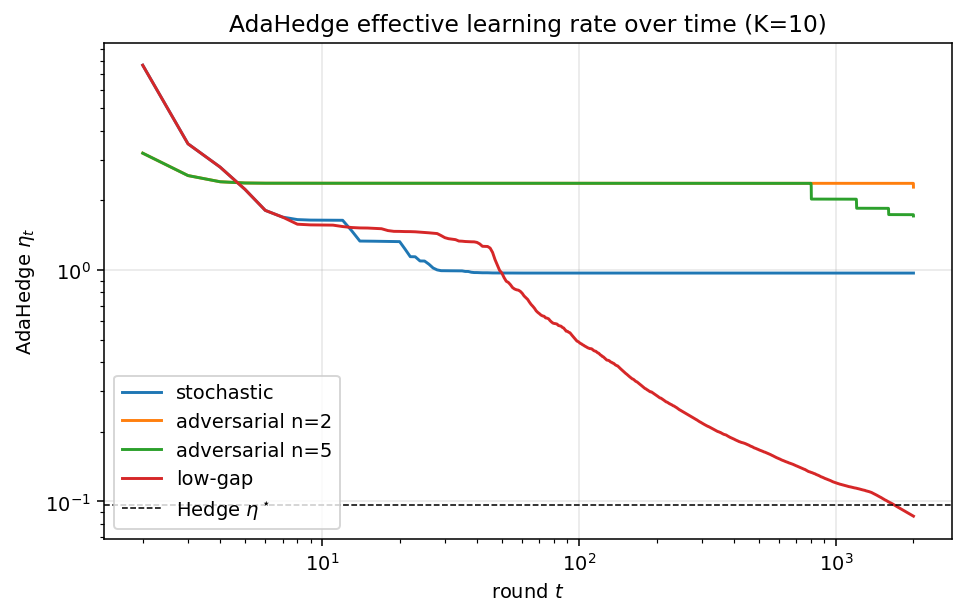

In [21]:
def trace_eta(loss_seq):
    algo = AdaHedge(K)
    etas = np.empty(loss_seq.shape[0])
    for t, l in enumerate(loss_seq):
        etas[t] = (np.log(K) / algo.Delta) if algo.Delta > 0 else np.inf
        algo.step(l)
    return etas

rng = np.random.default_rng(0)
etas_stoch = trace_eta(stochastic_losses(T, K, rng=rng))
etas_adv2  = trace_eta(adversarial_shifting(T, K, n_segments=2))
etas_adv5  = trace_eta(adversarial_shifting(T, K, n_segments=5))
etas_lg    = trace_eta(low_gap_losses(T, K, rng=np.random.default_rng(0)))

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, etas in [('stochastic',      etas_stoch),
                    ('adversarial n=2', etas_adv2),
                    ('adversarial n=5', etas_adv5),
                    ('low-gap',         etas_lg)]:
    ax.plot(np.arange(1, T+1), etas, label=label)
ax.axhline(hedge_eta_theory(T, K), color='k', ls='--', lw=0.8, label=r'Hedge $\eta^\star$')
ax.set_yscale('log'); ax.set_xscale('log')
ax.set_xlabel('round $t$'); ax.set_ylabel(r'AdaHedge $\eta_t$')
ax.set_title(f'AdaHedge effective learning rate over time (K={K})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, 'adahedge_eta')
plt.show()